# Depth Estimation Error Analysis

This notebook analyzes the errors between actual depth and predicted depth (depth_median) from the flower detection results.

## Section 1: Load and Explore the CSV Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the CSV
df = pd.read_csv('flower_detection_results_annotated.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics for Actual_Depth and Depth_Median:")
print(df[['Actual_Depth', 'Depth_Median']].describe())

Dataset shape: (55, 16)

Column names:
['Baseline', 'Position', 'Actual_Depth', 'Timestamp', 'Flower_ID', 'X1', 'Y1', 'X2', 'Y2', 'Confidence', 'Depth_Min', 'Depth_Max', 'Depth_Mean', 'Depth_Median', 'Valid_Pixels', 'Coverage_Percent']

First few rows:
  Baseline  Position  Actual_Depth                Timestamp  Flower_ID    X1  \
0    16_v1         1         0.475  2026-01-21 15:58:31.308          1  1027   
1    16_v1         1         0.475  2026-01-21 15:58:32.936          1  1023   
2    16_v1         1         0.475  2026-01-21 15:58:34.225          1  1020   
3    16_v1         1         0.475  2026-01-21 15:58:35.411          1  1021   
4    16_v1         1         0.475  2026-01-21 15:58:36.390          1  1019   

   Y1    X2   Y2  Confidence  Depth_Min  Depth_Max  Depth_Mean  Depth_Median  \
0  79  1388  546       0.799     0.2020     0.5966      0.3661        0.3201   
1  74  1391  546       0.799     0.2002     0.5988      0.3754        0.3382   
2  74  1389  545       0.7

## Section 2: Calculate Error Metrics

In [3]:
# Calculate errors
df['Error'] = df['Depth_Median'] - df['Actual_Depth']  # Prediction - Actual
df['Abs_Error'] = np.abs(df['Error'])
df['Percent_Error'] = (df['Abs_Error'] / df['Actual_Depth']) * 100

# Calculate error metrics
mae = df['Abs_Error'].mean()
rmse = np.sqrt(np.mean(df['Error']**2))
mape = df['Percent_Error'].mean()

print(f"Mean Absolute Error (MAE): {mae:.4f} m")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} m")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"\nError statistics:")
print(df[['Error', 'Abs_Error', 'Percent_Error']].describe())

# Error by baseline
print("\n\nError by Baseline:")
for baseline in df['Baseline'].unique():
    subset = df[df['Baseline'] == baseline]
    mae_b = subset['Abs_Error'].mean()
    rmse_b = np.sqrt(np.mean(subset['Error']**2))
    print(f"  {baseline}: MAE={mae_b:.4f}m, RMSE={rmse_b:.4f}m")

Mean Absolute Error (MAE): 0.1340 m
Root Mean Squared Error (RMSE): 0.1595 m
Mean Absolute Percentage Error (MAPE): 27.47%

Error statistics:
           Error  Abs_Error  Percent_Error
count  55.000000  55.000000      55.000000
mean   -0.116964   0.134000      27.473944
std     0.109381   0.087233      13.396624
min    -0.298300   0.016100       5.649123
25%    -0.196300   0.061600      18.232984
50%    -0.107900   0.107900      27.319035
75%    -0.017250   0.196300      36.336634
max     0.063200   0.298300      52.984014


Error by Baseline:
  16_v1: MAE=0.1529m, RMSE=0.1834m
  16_v2: MAE=0.1014m, RMSE=0.1237m
  11: MAE=0.1524m, RMSE=0.1714m


## Section 3: Scatter Plot - Actual vs Predicted Depth

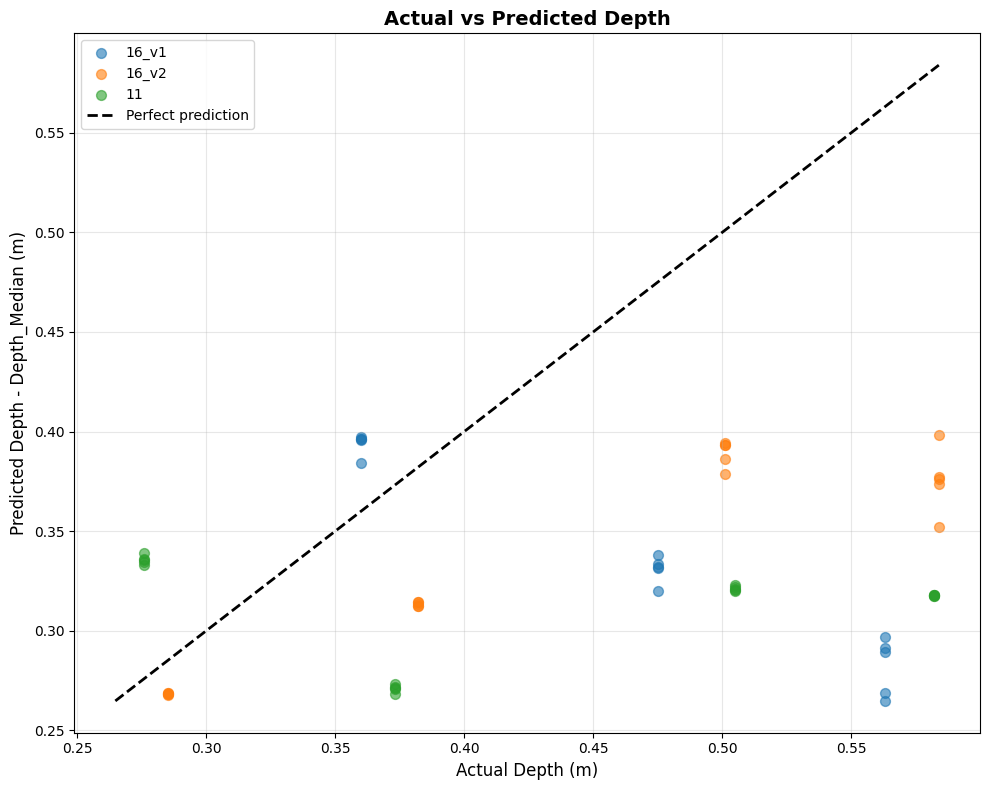

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

# Create color map for different baselines
baselines = df['Baseline'].unique()
colors = {'16_v1': '#1f77b4', '16_v2': '#ff7f0e', '11': '#2ca02c'}

for baseline in baselines:
    subset = df[df['Baseline'] == baseline]
    ax.scatter(subset['Actual_Depth'], subset['Depth_Median'], 
               label=baseline, alpha=0.6, s=50, color=colors[baseline])

# Add perfect prediction line (diagonal)
min_val = min(df['Actual_Depth'].min(), df['Depth_Median'].min())
max_val = max(df['Actual_Depth'].max(), df['Depth_Median'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect prediction', linewidth=2)

ax.set_xlabel('Actual Depth (m)', fontsize=12)
ax.set_ylabel('Predicted Depth - Depth_Median (m)', fontsize=12)
ax.set_title('Actual vs Predicted Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Matth\AppData\Local\Temp\ipykernel_77992\3725970729.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Baseline', y='Abs_Error', ax=ax2, palette=[colors[b] for b in df['Baseline'].unique()])


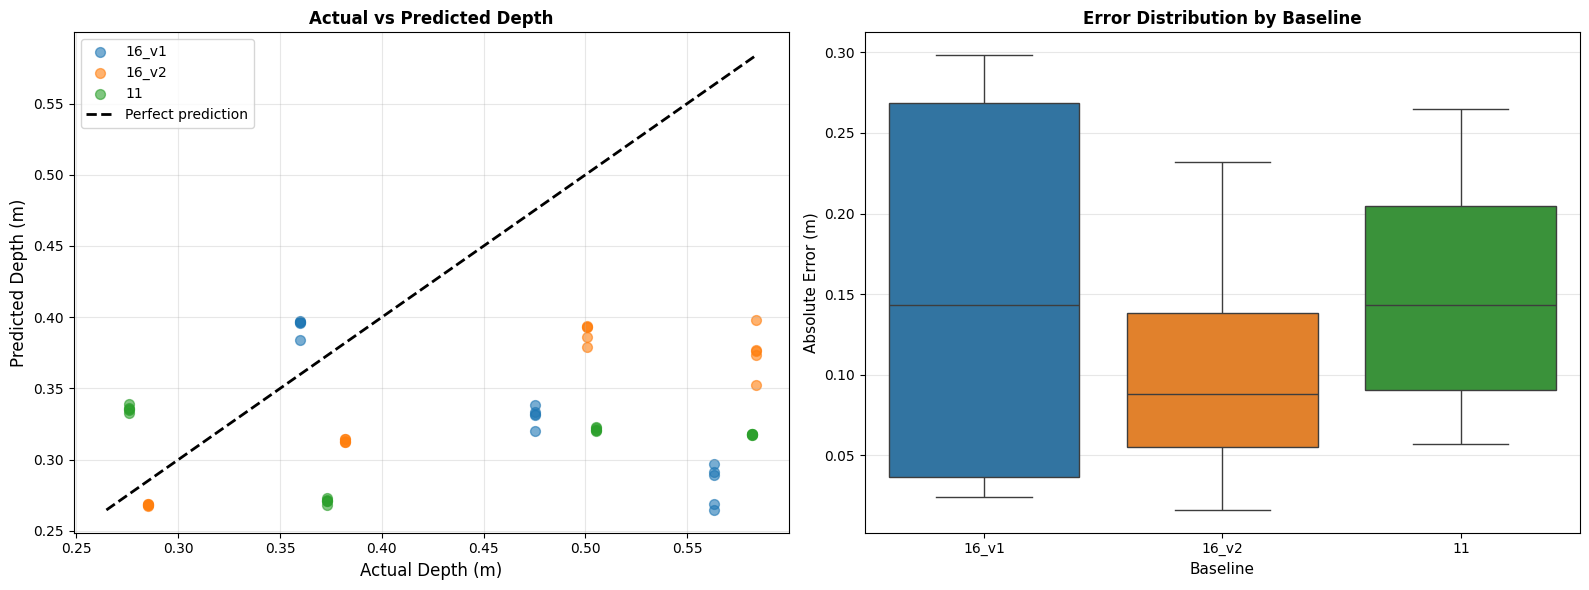

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Scatter plot of actual vs predicted depth
for baseline in df['Baseline'].unique():
    subset = df[df['Baseline'] == baseline]
    ax1.scatter(subset['Actual_Depth'], subset['Depth_Median'], 
               label=baseline, alpha=0.6, s=50, color=colors[baseline])

# Add perfect prediction line (diagonal)
min_val = min(df['Actual_Depth'].min(), df['Depth_Median'].min())
max_val = max(df['Actual_Depth'].max(), df['Depth_Median'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect prediction', linewidth=2)

ax1.set_xlabel('Actual Depth (m)', fontsize=12)
ax1.set_ylabel('Measured Depth (m)', fontsize=12)
ax1.set_title('Actual vs Measured Depth', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right plot: Box plot for absolute error by baseline
sns.boxplot(data=df, x='Baseline', y='Abs_Error', ax=ax2, palette=[colors[b] for b in df['Baseline'].unique()])
ax2.set_ylabel('Absolute Error (m)', fontsize=11)
ax2.set_xlabel('Baseline', fontsize=11)
ax2.set_title('Error Distribution by Baseline', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Section 3.1: Line Plot - Predictions vs Actual for All Models

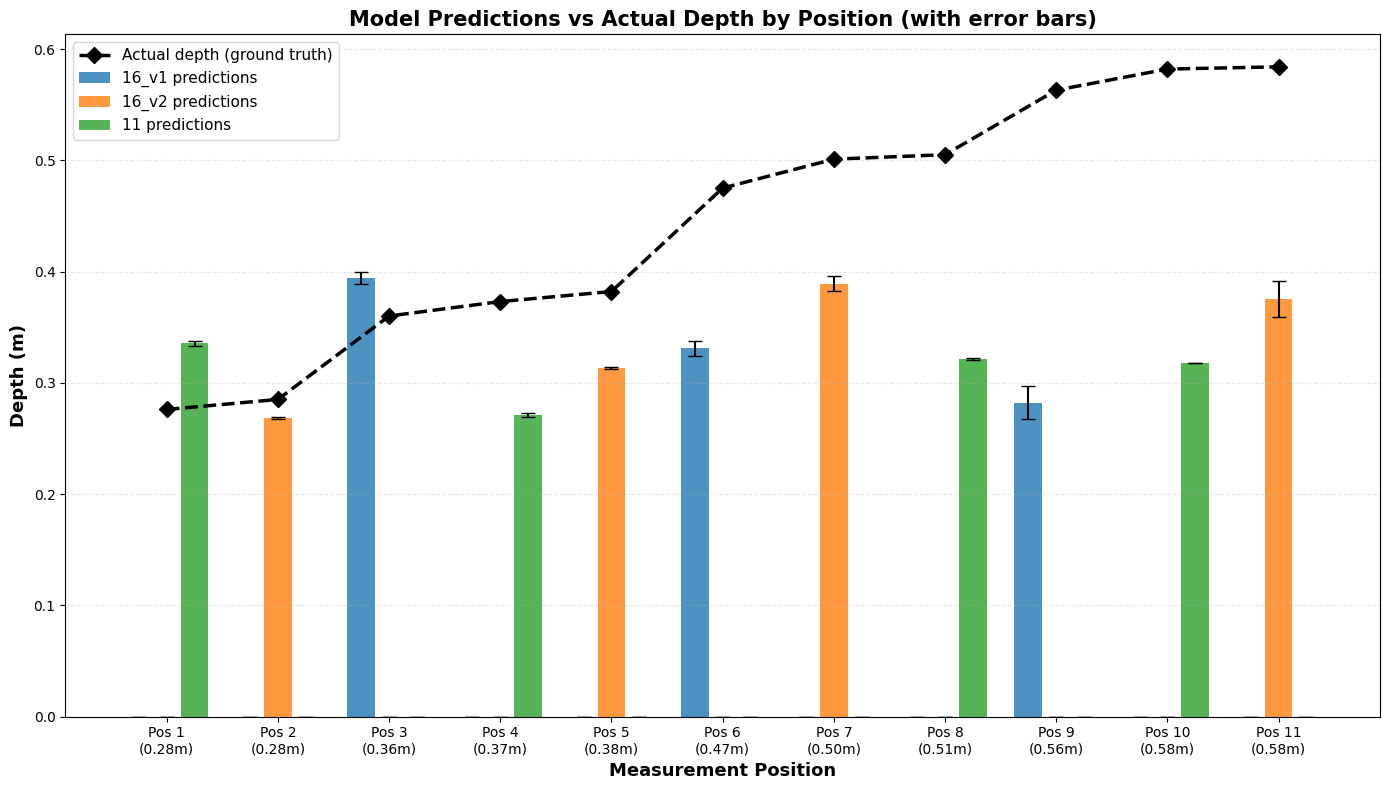


Model Performance Summary:
16_v1    | MAE: 0.1529m | RMSE: 0.1834m | MAPE: 29.87%
16_v2    | MAE: 0.1014m | RMSE: 0.1237m | MAPE: 20.47%
11       | MAE: 0.1524m | RMSE: 0.1714m | MAPE: 32.68%


In [9]:
# Group by actual depth (position) and calculate mean predictions and std
position_data = df.groupby(['Actual_Depth', 'Baseline']).agg({
    'Depth_Median': ['mean', 'std', 'count']
}).reset_index()

position_data.columns = ['Actual_Depth', 'Baseline', 'Mean_Pred', 'Std_Pred', 'Count']

fig, ax = plt.subplots(figsize=(14, 8))

# Get unique actual depths and baselines
actual_depths = sorted(position_data['Actual_Depth'].unique())
x = np.arange(len(actual_depths))
width = 0.25  # Width of bars

# Plot bars for each baseline with error bars
for i, baseline in enumerate(baselines):
    subset = position_data[position_data['Baseline'] == baseline]
    # Ensure subset is in same order as actual_depths
    means = [subset[subset['Actual_Depth'] == d]['Mean_Pred'].values[0] if len(subset[subset['Actual_Depth'] == d]) > 0 else 0 for d in actual_depths]
    stds = [subset[subset['Actual_Depth'] == d]['Std_Pred'].values[0] if len(subset[subset['Actual_Depth'] == d]) > 0 else 0 for d in actual_depths]
    
    ax.bar(x + i*width, means, width, yerr=stds, 
           label=f'{baseline} predictions', alpha=0.8, 
           color=colors[baseline], capsize=5)

# Plot actual depth as line
ax.plot(x + width, actual_depths, 'k--', marker='D', markersize=8,
        linewidth=2.5, label='Actual depth (ground truth)', zorder=10)

ax.set_xlabel('Measurement Position', fontsize=13, fontweight='bold')
ax.set_ylabel('Depth (m)', fontsize=13, fontweight='bold')
ax.set_title('Model Predictions vs Actual Depth by Position (with error bars)', fontsize=15, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([f'Pos {i+1}\n({d:.2f}m)' for i, d in enumerate(actual_depths)])
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.show()

# Print summary statistics for each model
print("\nModel Performance Summary:")
print("="*60)
for baseline in baselines:
    subset = df[df['Baseline'] == baseline]
    mae_b = subset['Abs_Error'].mean()
    rmse_b = np.sqrt(np.mean(subset['Error']**2))
    mape_b = subset['Percent_Error'].mean()
    print(f"{baseline:8} | MAE: {mae_b:.4f}m | RMSE: {rmse_b:.4f}m | MAPE: {mape_b:.2f}%")

## Section 4: Residual Plot - Error Distribution

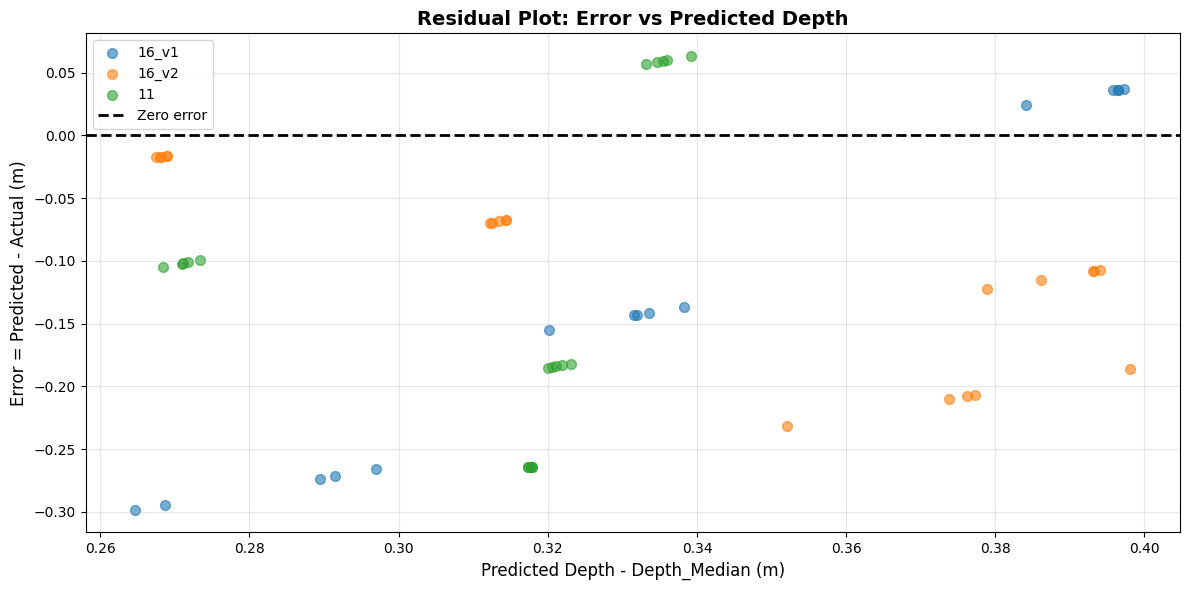

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for baseline in baselines:
    subset = df[df['Baseline'] == baseline]
    ax.scatter(subset['Depth_Median'], subset['Error'], 
               label=baseline, alpha=0.6, s=50, color=colors[baseline])

# Add reference line at zero error
ax.axhline(y=0, color='k', linestyle='--', linewidth=2, label='Zero error')

ax.set_xlabel('Predicted Depth - Depth_Median (m)', fontsize=12)
ax.set_ylabel('Error = Predicted - Actual (m)', fontsize=12)
ax.set_title('Residual Plot: Error vs Predicted Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: Histogram - Error Magnitude

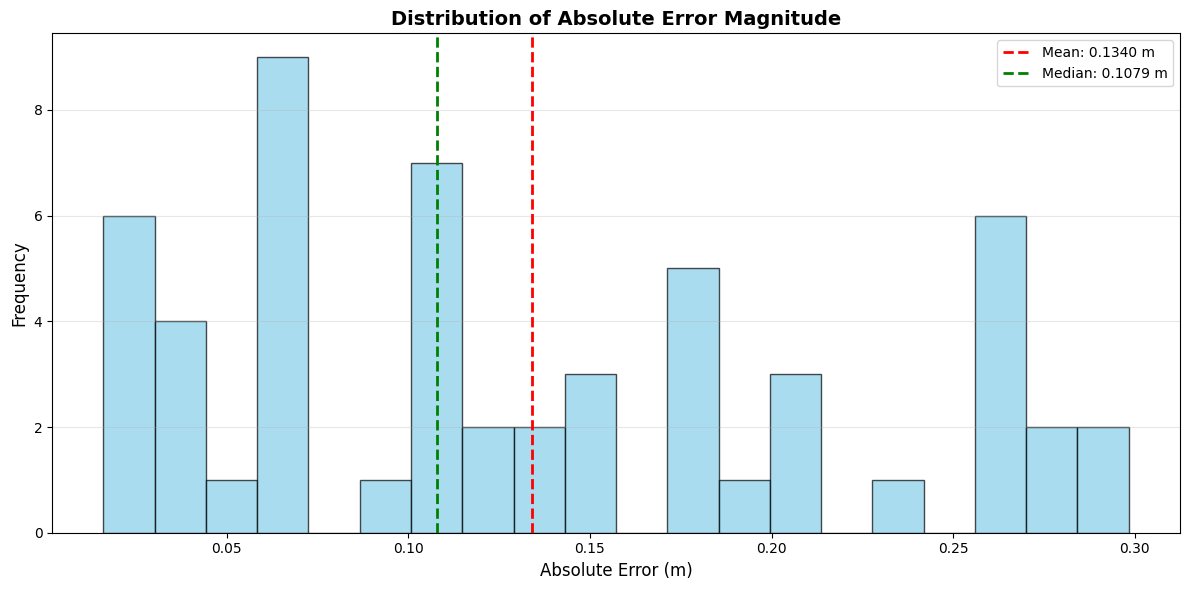

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['Abs_Error'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(mae, color='red', linestyle='--', linewidth=2, label=f'Mean: {mae:.4f} m')
ax.axvline(df['Abs_Error'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Abs_Error"].median():.4f} m')

ax.set_xlabel('Absolute Error (m)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Absolute Error Magnitude', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Section 6: Box Plot - Error Statistics by Baseline

C:\Users\Matth\AppData\Local\Temp\ipykernel_77992\317601987.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Baseline', y='Abs_Error', ax=axes, palette=[colors[b] for b in df['Baseline'].unique()])


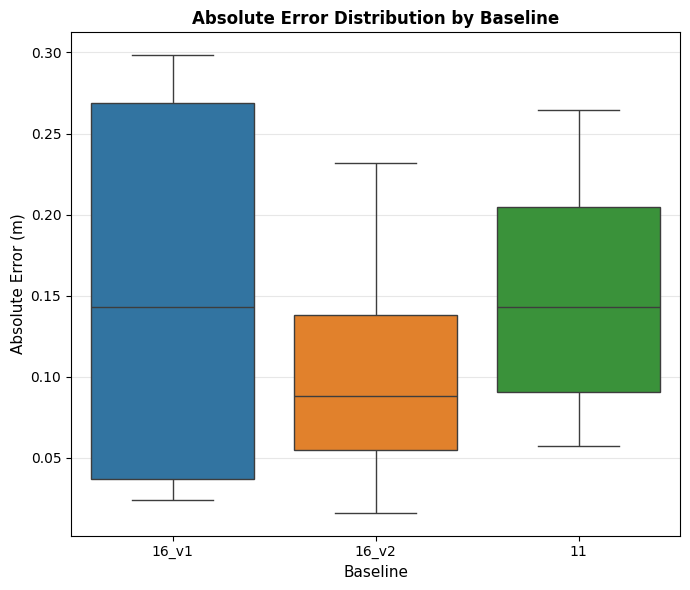

In [7]:
fig, axes = plt.subplots(1, 1, figsize=(7, 6))

# Box plot for absolute error by baseline
sns.boxplot(data=df, x='Baseline', y='Abs_Error', ax=axes, palette=[colors[b] for b in df['Baseline'].unique()])
axes.set_ylabel('Absolute Error (m)', fontsize=11)
axes.set_xlabel('Baseline', fontsize=11)
axes.set_title('Absolute Error Distribution by Baseline', fontsize=12, fontweight='bold')
axes.grid(True, alpha=0.3, axis='y')


plt.tight_layout()
plt.show()

## Section 7: Error by Position and Baseline

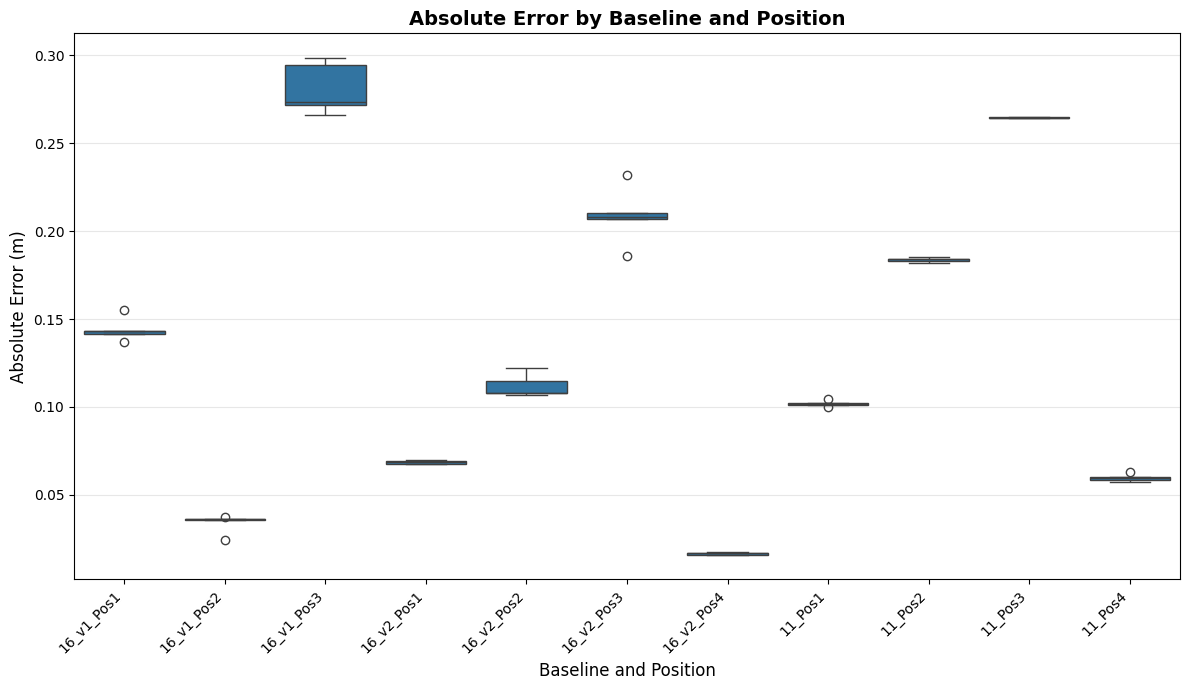

Error Statistics by Baseline and Position:

11 - Position 1 (Actual: 0.373m):
  Predicted: 0.2711 ± 0.0018
  MAE: 0.1019 m
  RMSE: 0.1019 m

11 - Position 2 (Actual: 0.505m):
  Predicted: 0.3213 ± 0.0012
  MAE: 0.1837 m
  RMSE: 0.1837 m

11 - Position 3 (Actual: 0.582m):
  Predicted: 0.3177 ± 0.0003
  MAE: 0.2643 m
  RMSE: 0.2643 m

11 - Position 4 (Actual: 0.276m):
  Predicted: 0.3357 ± 0.0022
  MAE: 0.0597 m
  RMSE: 0.0597 m

16_v1 - Position 1 (Actual: 0.475m):
  Predicted: 0.3311 ± 0.0067
  MAE: 0.1439 m
  RMSE: 0.1440 m

16_v1 - Position 2 (Actual: 0.360m):
  Predicted: 0.3940 ± 0.0056
  MAE: 0.0340 m
  RMSE: 0.0344 m

16_v1 - Position 3 (Actual: 0.563m):
  Predicted: 0.2823 ± 0.0145
  MAE: 0.2807 m
  RMSE: 0.2810 m

16_v2 - Position 1 (Actual: 0.382m):
  Predicted: 0.3134 ± 0.0010
  MAE: 0.0686 m
  RMSE: 0.0686 m

16_v2 - Position 2 (Actual: 0.501m):
  Predicted: 0.3891 ± 0.0065
  MAE: 0.1119 m
  RMSE: 0.1121 m

16_v2 - Position 3 (Actual: 0.584m):
  Predicted: 0.3755 ± 0.0163
  

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

# Create a combined label for baseline and position
df['Baseline_Pos'] = df['Baseline'] + '_Pos' + df['Position'].astype(str)

# Plot
sns.boxplot(data=df, x='Baseline_Pos', y='Abs_Error', ax=ax)
ax.set_ylabel('Absolute Error (m)', fontsize=12)
ax.set_xlabel('Baseline and Position', fontsize=12)
ax.set_title('Absolute Error by Baseline and Position', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print detailed stats
print("Error Statistics by Baseline and Position:")
print("=" * 80)
for baseline in sorted(df['Baseline'].unique()):
    for pos in sorted(df[df['Baseline']==baseline]['Position'].unique()):
        subset = df[(df['Baseline']==baseline) & (df['Position']==pos)]
        print(f"\n{baseline} - Position {pos} (Actual: {subset['Actual_Depth'].iloc[0]:.3f}m):")
        print(f"  Predicted: {subset['Depth_Median'].mean():.4f} ± {subset['Depth_Median'].std():.4f}")
        print(f"  MAE: {subset['Abs_Error'].mean():.4f} m")
        print(f"  RMSE: {np.sqrt(np.mean(subset['Error']**2)):.4f} m")

## Section 8: Summary Statistics and Insights

In [8]:
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"\nOverall Error Metrics:")
print(f"  Mean Absolute Error (MAE):          {mae:.4f} m")
print(f"  Root Mean Squared Error (RMSE):    {rmse:.4f} m")
print(f"  Mean Absolute Percentage Error:    {mape:.2f}%")
print(f"  Median Absolute Error:             {df['Abs_Error'].median():.4f} m")
print(f"  Min Absolute Error:                {df['Abs_Error'].min():.4f} m")
print(f"  Max Absolute Error:                {df['Abs_Error'].max():.4f} m")
print(f"  Std Dev of Error:                  {df['Abs_Error'].std():.4f} m")

print(f"\n\nDepth Range Analysis:")
print(f"  Actual depth range: {df['Actual_Depth'].min():.3f} - {df['Actual_Depth'].max():.3f} m")
print(f"  Predicted depth range: {df['Depth_Median'].min():.3f} - {df['Depth_Median'].max():.3f} m")

print(f"\n\nBias Analysis (Systematic Error):")
mean_error = df['Error'].mean()
print(f"  Mean signed error: {mean_error:.4f} m")
if mean_error > 0:
    print(f"  → Prediction is OVER-ESTIMATING depth by ~{mean_error:.4f} m on average")
else:
    print(f"  → Prediction is UNDER-ESTIMATING depth by ~{abs(mean_error):.4f} m on average")

print(f"\n\nError Distribution:")
print(f"  Errors within 0.05m:  {len(df[df['Abs_Error'] <= 0.05])}/{len(df)} ({100*len(df[df['Abs_Error'] <= 0.05])/len(df):.1f}%)")
print(f"  Errors within 0.10m:  {len(df[df['Abs_Error'] <= 0.10])}/{len(df)} ({100*len(df[df['Abs_Error'] <= 0.10])/len(df):.1f}%)")
print(f"  Errors within 0.15m:  {len(df[df['Abs_Error'] <= 0.15])}/{len(df)} ({100*len(df[df['Abs_Error'] <= 0.15])/len(df):.1f}%)")

SUMMARY STATISTICS

Overall Error Metrics:
  Mean Absolute Error (MAE):          0.1340 m
  Root Mean Squared Error (RMSE):    0.1595 m
  Mean Absolute Percentage Error:    27.47%
  Median Absolute Error:             0.1079 m
  Min Absolute Error:                0.0161 m
  Max Absolute Error:                0.2983 m
  Std Dev of Error:                  0.0872 m


Depth Range Analysis:
  Actual depth range: 0.276 - 0.584 m
  Predicted depth range: 0.265 - 0.398 m


Bias Analysis (Systematic Error):
  Mean signed error: -0.1170 m
  → Prediction is UNDER-ESTIMATING depth by ~0.1170 m on average


Error Distribution:
  Errors within 0.05m:  10/55 (18.2%)
  Errors within 0.10m:  21/55 (38.2%)
  Errors within 0.15m:  34/55 (61.8%)
